# 03 — Gráficas de abundancias y comparación observacional

Este notebook genera las figuras principales para la memoria:

1. Evolución de todas las abundancias para $t_0=10$ s.
2. Evolución de todas las abundancias para $t_0=50$ s.
3. Comparación de observables clave entre modelos y datos observacionales.
4. Figura independiente del problema del litio.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "grid"])
except Exception as exc:
    print("scienceplots no disponible, usando estilo por defecto:", exc)

BASE = Path.cwd()
FIG_DIR = BASE / "figures"
DATA_DIR = BASE / "data"
TAB_DIR = BASE / "tables"
for d in [FIG_DIR, DATA_DIR, TAB_DIR]:
    d.mkdir(exist_ok=True)

model10 = pd.read_csv(DATA_DIR / "bbn_evolution_t0_10s.csv")
model50 = pd.read_csv(DATA_DIR / "bbn_evolution_t0_50s.csv")
all_models = pd.read_csv(DATA_DIR / "bbn_evolution_all_models.csv")
obs = pd.read_csv(DATA_DIR / "observational_abundances.csv")
finals = pd.read_csv(DATA_DIR / "bbn_final_compact.csv")

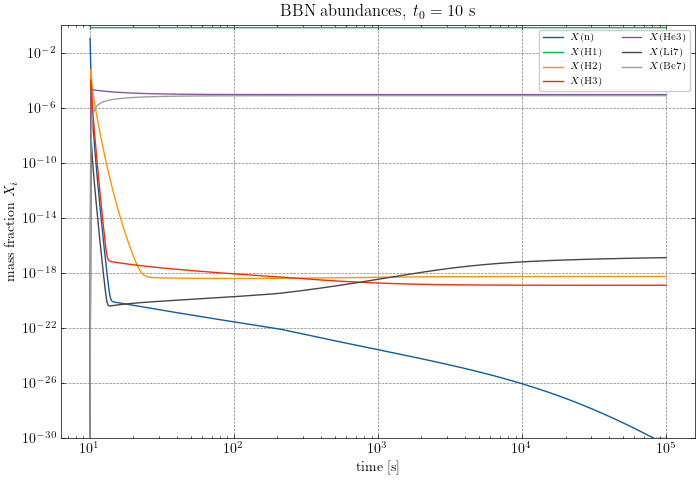

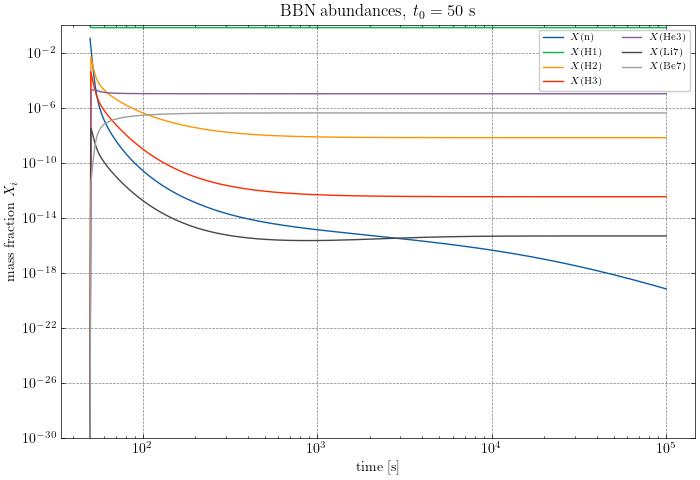

In [18]:
# Helper para detectar columnas X_i.
def abundance_columns(df):
    cols = [c for c in df.columns if c.startswith("X_") and c not in ["X_He4"]]
    # Dejamos X_He4 fuera porque es duplicado de X_he4 si existe.
    return cols

def pretty_label(col):
    label_map = {
        "X_h1": r"$X(^1\mathrm{H})$", "X_p": r"$X(p)$",
        "X_h2": r"$X(^2\mathrm{H})$", "X_d": r"$X(d)$",
        "X_h3": r"$X(^3\mathrm{H})$", "X_t": r"$X(t)$",
        "X_he3": r"$X(^3\mathrm{He})$", "X_he4": r"$X(^4\mathrm{He})$",
        "X_li7": r"$X(^7\mathrm{Li})$", "X_be7": r"$X(^7\mathrm{Be})$",
    }
    if col in label_map:
        return label_map[col]
    if col.startswith("X_"):
        return r"$X($" + col[2:] + r"$)$"
    return col

def plot_all_abundances(df, outname, title):
    cols = abundance_columns(df)
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    for col in cols:
        y = df[col].clip(lower=1e-30)
        ax.loglog(df["t_s"], y, label=pretty_label(col))
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"mass fraction $X_i$")
    ax.set_ylim(1e-30, 1.2)
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / outname)
    plt.show()

plot_all_abundances(model10, "fig_all_abundances_t0_10s.pdf", r"BBN abundances, $t_0=10$ s")
plot_all_abundances(model50, "fig_all_abundances_t0_50s.pdf", r"BBN abundances, $t_0=50$ s")

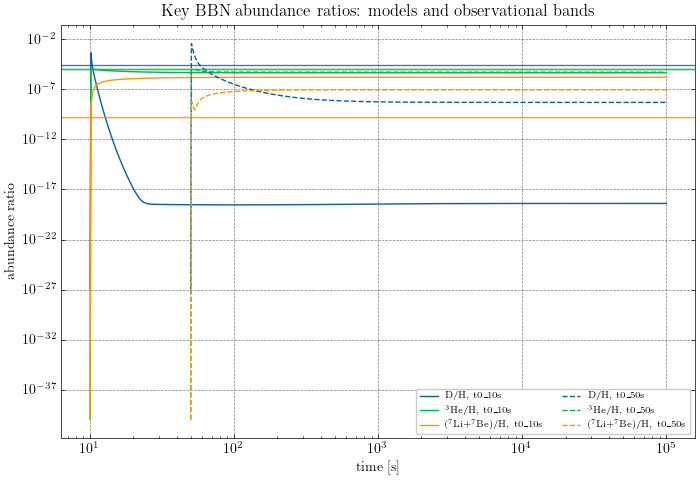

In [19]:
# Comparación de observables clave en evolución temporal.
# Se usan los mismos colores para cada composición y distintos estilos para cada modelo.

obs_map = {row["model_column"]: row for _, row in obs.iterrows()}
plot_quantities = [
    ("D/H", r"D/H"),
    ("He3/H", r"$^3$He/H"),
    ("Li7_plus_Be7_over_H", r"$(^7$Li+$^7$Be)/H"),
]
colors = {"D/H": "C0", "He3/H": "C1", "Li7_plus_Be7_over_H": "C2"}
linestyles = {"t0_10s": "-", "t0_50s": "--"}

fig, ax = plt.subplots(figsize=(7.2, 5.0))
for model_name, df in [("t0_10s", model10), ("t0_50s", model50)]:
    for col, label in plot_quantities:
        ax.loglog(df["t_s"], df[col].clip(lower=1e-40), linestyle=linestyles[model_name], color=colors[col], label=f"{label}, {model_name}")

# Bandas observacionales horizontales
for col, label in plot_quantities:
    if col in obs_map:
        val = obs_map[col]["value"]
        sig = obs_map[col]["sigma"]
        ax.axhspan(max(val-sig, 1e-40), val+sig, color=colors[col], alpha=0.15)
        ax.axhline(val, color=colors[col], lw=0.9, alpha=0.8)

ax.set_xlabel("time [s]")
ax.set_ylabel("abundance ratio")
ax.set_title("Key BBN abundance ratios: models and observational bands")
ax.legend(fontsize=6.5, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_key_ratios_evolution_vs_observed.pdf")
plt.show()

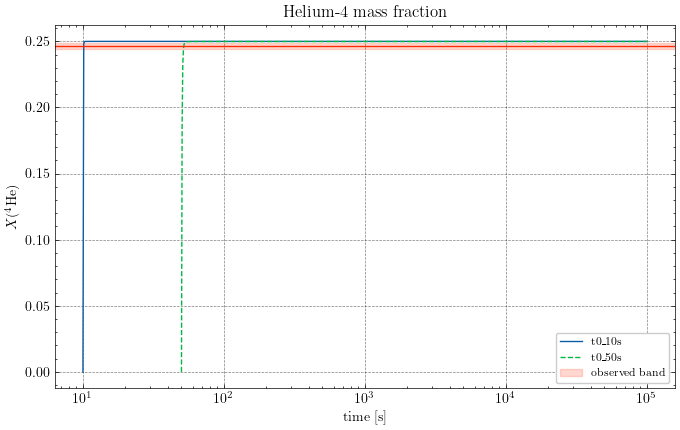

In [20]:
# Helio-4 por separado, porque es una fracción másica de orden 0.25.
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for model_name, df in [("t0_10s", model10), ("t0_50s", model50)]:
    ax.semilogx(df["t_s"], df["X_He4"], linestyle=linestyles[model_name], label=model_name)

he = obs[obs["model_column"] == "X_He4"].iloc[0]
ax.axhspan(he["value"]-he["sigma"], he["value"]+he["sigma"], color="C3", alpha=0.18, label="observed band")
ax.axhline(he["value"], color="C3", lw=1.0)
ax.set_xlabel("time [s]")
ax.set_ylabel(r"$X(^4\mathrm{He})$")
ax.set_title(r"Helium-4 mass fraction")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_he4_evolution_vs_observed.pdf")
plt.show()

In [21]:
# Comparación final: barras con modelos y observación.
# Para cocientes pequeños usamos escala logarítmica.
compare_rows = []
for _, ob in obs.iterrows():
    col = ob["model_column"]
    for _, f in finals.iterrows():
        compare_rows.append({
            "observable": ob["observable"],
            "kind": f["model"],
            "value": f[col],
            "sigma": np.nan,
            "source": "pynucastro model",
        })
    compare_rows.append({
        "observable": ob["observable"],
        "kind": "observed",
        "value": ob["value"],
        "sigma": ob["sigma"],
        "source": ob["source_key"],
    })
compare = pd.DataFrame(compare_rows)
compare.to_csv(DATA_DIR / "comparison_models_vs_observed.csv", index=False)
compare

,observable,kind,value,sigma,source
0,D/H,t0_50s,4.979074e-09,NaN,pynucastro model
1,D/H,t0_10s,4.013645e-19,NaN,pynucastro model
2,D/H,observed,2.527000e-05,3.000000e-07,Cooke2018
3,Yp_He4,t0_50s,2.498882e-01,NaN,pynucastro model
4,Yp_He4,t0_10s,2.499795e-01,NaN,pynucastro model
5,Yp_He4,observed,2.462000e-01,2.200000e-03,Aver2021
6,He3/H,t0_50s,5.209399e-06,NaN,pynucastro model
7,He3/H,t0_10s,4.542966e-06,NaN,pynucastro model
8,He3/H,observed,1.100000e-05,2.000000e-06,Steigman2010
9,Li7/H,t0_50s,9.013511e-08,NaN,pynucastro model


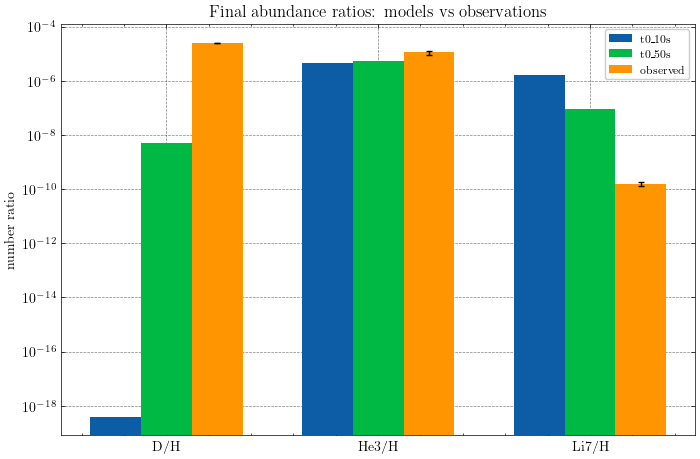

In [22]:
# Bar plot de D/H, He3/H y Li7/H en log.
small_obs = ["D/H", "He3/H", "Li7/H"]
sub = compare[compare["observable"].isin(small_obs)].copy()
fig, ax = plt.subplots(figsize=(7.2, 4.8))
labels = small_obs
x = np.arange(len(labels))
width = 0.24
kinds = ["t0_10s", "t0_50s", "observed"]
for j, kind in enumerate(kinds):
    vals = []
    errs = []
    for lab in labels:
        row = sub[(sub["observable"] == lab) & (sub["kind"] == kind)].iloc[0]
        vals.append(row["value"])
        errs.append(row["sigma"] if np.isfinite(row["sigma"]) else 0.0)
    ax.bar(x + (j-1)*width, vals, width=width, label=kind, yerr=errs, capsize=2 if kind=="observed" else 0)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("number ratio")
ax.set_title("Final abundance ratios: models vs observations")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_final_ratios_bar_models_vs_observed.pdf")
plt.show()

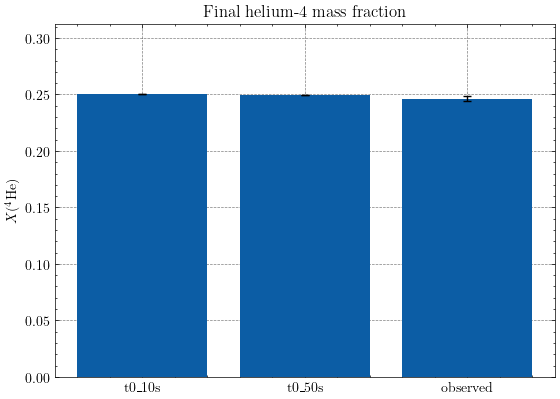

In [23]:
# Bar plot de He4 separado.
sub = compare[compare["observable"] == "Yp_He4"].copy()
fig, ax = plt.subplots(figsize=(5.8, 4.2))
labels = ["t0_10s", "t0_50s", "observed"]
vals = [sub[sub["kind"] == k]["value"].iloc[0] for k in labels]
errs = [0.0, 0.0, sub[sub["kind"] == "observed"]["sigma"].iloc[0]]
ax.bar(labels, vals, yerr=errs, capsize=3)
ax.set_ylabel(r"$X(^4\mathrm{He})$")
ax.set_title(r"Final helium-4 mass fraction")
ax.set_ylim(0, max(vals)*1.25 if max(vals) > 0 else 0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_final_he4_bar_models_vs_observed.pdf")
plt.show()

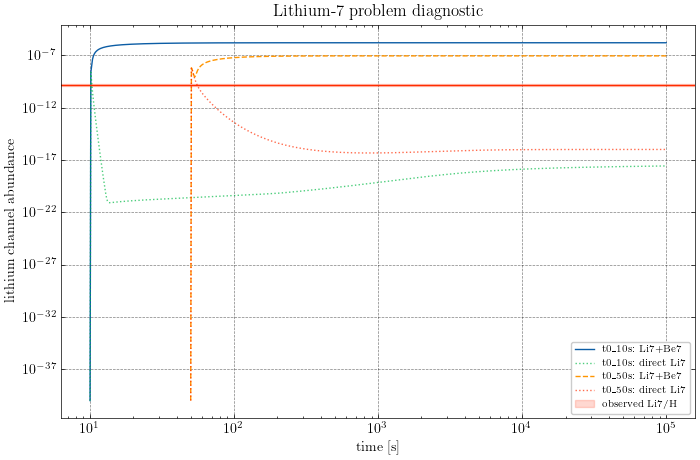

In [24]:
# Gráfica independiente del litio: evolución y valor observado.
li_obs = obs[obs["model_column"] == "Li7_plus_Be7_over_H"].iloc[0]
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for model_name, df in [("t0_10s", model10), ("t0_50s", model50)]:
    ax.loglog(df["t_s"], df["Li7_plus_Be7_over_H"].clip(lower=1e-40), linestyle=linestyles[model_name], label=f"{model_name}: Li7+Be7")
    if "Li7/H" in df:
        ax.loglog(df["t_s"], df["Li7/H"].clip(lower=1e-40), linestyle=":", alpha=0.7, label=f"{model_name}: direct Li7")

ax.axhspan(li_obs["value"]-li_obs["sigma"], li_obs["value"]+li_obs["sigma"], color="C3", alpha=0.18, label="observed Li7/H")
ax.axhline(li_obs["value"], color="C3", lw=1.0)
ax.set_xlabel("time [s]")
ax.set_ylabel(r"lithium channel abundance")
ax.set_title(r"Lithium-7 problem diagnostic")
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_lithium7_problem_comparison.pdf")
plt.show()